# Sensor Count Sweep: Electrical Impedance Tomography

- PDE: $-\nabla \cdot (a \nabla u) = 0$
- Latent dimension: $d_a = 6$ (MCMC dimension)
- Observations: Neumann boundary flux
- Sweep: $n_{\mathrm{obs}} \in \{31, 62, 124\}$ boundary points, clean observations

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "n_obs": n}
    for s, n in itertools.product([42, 123, 7], [31, 62, 124])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro

from src.problems.eit import EIT, one_hot_g_l, compute_u_and_grad_eit, mollifier_eit
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, chi2_ppc,
    plot_field_comparison, plot_calibration_overlay,
    plot_sensor_sweep, plot_std_multi_panel,
    plot_sweep_summary_table, plot_trace,
    plot_eit_ground_truth, plot_eit_observation_data,
    bootstrap_metric_ci, compute_error_std_correlation,
    tune_sigma, recommended_nuts_config,
    compute_prior_predictive, build_prior_result,
    load_problem, get_nf_mode, make_log_prior, make_numpyro_model,
    run_map_estimation,
    sample_unconditional_prior,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results,
)

CHECKPOINT_PATH = Path('../runs/final_eit/weights/best.pt')
TEST_DATA_PATH = '../data/eit/inverse_EIT_in.mat'
TEST_IDX = 0
N_OBS_VALUES = [31, 62, 124]
REF_N_OBS = max(N_OBS_VALUES)
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]
    N_OBS_VALUES = [PARAMETER_GRID[_task_id]["n_obs"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = EIT(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_a_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()

print(f"Latent dim (coeff): {d}")
print(f"Latent dim (combined): {problem.BETA_SIZE_U}")

Loading data...


  Test: a=(20, 1024, 1), u=[[[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.8746724 ]
  [ 0.761118  ]
  [ 0.6172527 ]]

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [ 0.3165446 ]
  [ 0.12906456]
  [-0.06325148]]

 [[ 1.        ]
  [ 0.98346853]
  [ 0.9351161 ]
  ...
  [-0.2334332 ]
  [-0.40426344]
  [-0.5620679 ]]

 ...

 [[ 1.        ]
  [ 0.981173  ]
  [ 0.9261911 ]
  ...
  [-0.8738502 ]
  [-0.7647962 ]
  [-0.62749803]]

 [[ 1.        ]
  [ 0.9797001 ]
  [ 0.9204757 ]
  ...
  [ 0.10988297]
  [ 0.30528814]
  [ 0.48864248]]

 [[ 1.        ]
  [ 0.9791928 ]
  [ 0.918509  ]
  ...
  [ 0.918509  ]
  [ 0.9791928 ]
  [ 1.        ]]]
  Boundary points: 124 (left=32, top=31, right=31, bottom=30)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 113,702 params


  Initialized u: 83,805 params
  Initialized a: 81,805 params


E0614 17:15:03.450333      24 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 15,420 params
Loading checkpoint: ../runs/final_eit/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim (coeff): 6
Latent dim (combined): 26


In [4]:
def make_log_likelihood(x_obs_arg, u_obs_arg, normals_arg):
    """Create EIT Neumann likelihood closure with specific boundary points & normals."""
    def log_likelihood_fn(beta_a, sigma):
        beta_b = beta_a[None, :]
        g_l_onehot = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot], axis=-1)

        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'],
            x_obs_arg[0], beta_u[0], g_l_scalar
        )

        a_vals = problem.models['a'].apply(
            {'params': params['a']}, x_obs_arg, beta_b
        )[0]

        neumann_pred = a_vals * (du_vals[:, 0] * normals_arg[:, 0] + du_vals[:, 1] * normals_arg[:, 1])
        neumann_obs = u_obs_arg[0, :, 0]

        sq_err = jnp.sum((neumann_pred - neumann_obs) ** 2)
        n = neumann_obs.shape[0]
        return -0.5 * sq_err / (sigma ** 2) - 0.5 * n * jnp.log(2 * jnp.pi * sigma ** 2)
    return log_likelihood_fn


def decode_posterior(beta_a_samples, a_true_ref, batch_size=200):
    """Decode beta samples -> coefficient + solution predictions.

    a_true_ref: (1, n_mesh, 1)
    """
    n_s = beta_a_samples.shape[0]
    g_l_onehot = one_hot_g_l(problem._current_g_l)  # (1, 20)
    a_preds, u_preds = [], []

    for i in range(0, n_s, batch_size):
        batch_beta = beta_a_samples[i:i + batch_size]
        n_b = batch_beta.shape[0]
        x_tile = jnp.tile(x_full, (n_b, 1, 1))

        a_b = problem.models['a'].apply({'params': params['a']}, x_tile, batch_beta)
        a_b = a_b[..., None] if a_b.ndim == 2 else a_b
        a_preds.append(a_b)

        g_l_tiled = jnp.tile(g_l_onehot, (n_b, 1))
        beta_u_b = jnp.concatenate([batch_beta, g_l_tiled], axis=-1)
        g_l_tiled_for_moll = jnp.tile(problem._current_g_l, (n_b, 1))

        u_b = problem.models['u'].apply({'params': params['u']}, x_tile, beta_u_b)
        if u_b.ndim == 2:
            u_b = u_b[..., None]
        u_b = mollifier_eit(u_b.squeeze(-1), x_tile, g_l_tiled_for_moll)
        u_preds.append(u_b)

    a_pred = jnp.concatenate(a_preds, axis=0)   # (n_s, n_mesh, 1)
    u_pred = jnp.concatenate(u_preds, axis=0)   # (n_s, n_mesh)

    return a_pred, u_pred

## 2. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=100.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.25),
)


def run_condition(n_obs, rng_key):
    rng_key, obs_key, mcmc_key = random.split(rng_key, 3)
    label = f"n_obs={n_obs}"
    print(f"\n{'='*60}\n  {label}\n{'='*60}")

    obs_indices = problem.sample_observation_indices(n_points, n_obs, 'random', obs_key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    normals = problem._active_boundary_normals_jax

    n_bd_actual = x_obs.shape[1]
    print(f"  Boundary points: {n_bd_actual}, normals: {normals.shape}")

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng_key)
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    map_rmse = float(rmse(a_map, a_true[0]))
    print(f"  MAP RMSE (a): {map_rmse:.6f}")

    log_lik_fn = make_log_likelihood(x_obs, u_obs, normals)
    numpyro_model = make_numpyro_model(d, log_prior_fn, log_lik_fn, sample_name="beta_a")

    # Tune sigma via pilot MCMC
    def _model_factory(sigma):
        def _model():
            numpyro_model(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        a_preds = []
        for i in range(len(beta_samples)):
            beta_i = beta_samples[i:i+1]
            x_full_tiled = jnp.tile(x_full, (1, 1, 1))
            a_pred = problem.models['a'].apply({'params': params['a']}, x_full_tiled, beta_i)
            a_preds.append(np.array(a_pred[0]))
        return np.stack(a_preds)

    rng_key, tune_key = jax.random.split(rng_key)
    sigma, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_a_mode,
        sigma_candidates=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
        sample_name='beta_a',
    )
    print(f"  sigma (tuned): {sigma:.6f}")

    nuts_cfg = recommended_nuts_config(d, sigma)
    print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
          f"max_tree_depth={nuts_cfg['max_tree_depth']}")

    mcmc, timing = run_mcmc(
        numpyro_model, {"beta_a": beta_a_mode}, {"sigma": sigma}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc.print_summary(exclude_deterministic=True)

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta_a", total_samples=NUM_CHAINS * NUM_SAMPLES)
    beta_a_samples = diag['samples']

    a_pred, u_pred = decode_posterior(beta_a_samples, a_true)
    a_np = np.array(a_pred[:, :, 0])

    metrics = compute_standard_metrics(a_np, a_true_np)

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, np.mean(a_np, axis=0), np.std(a_np, axis=0),
    )

    # Chi-squared PPC (EIT: uses Neumann flux predictions)
    def compute_neumann_for_beta(beta_a_single):
        beta_b = beta_a_single[None, :]
        g_l_onehot_s = one_hot_g_l(problem._current_g_l)
        beta_u = jnp.concatenate([beta_b, g_l_onehot_s], axis=-1)
        g_l_scalar = problem._current_g_l[0, 0]
        _, du_vals = compute_u_and_grad_eit(
            params['u'], problem.models['u'], x_obs[0], beta_u[0], g_l_scalar
        )
        a_vals = problem.models['a'].apply({'params': params['a']}, x_obs, beta_b)[0]
        return a_vals * (du_vals[:, 0] * normals[:, 0] + du_vals[:, 1] * normals[:, 1])

    n_pred = min(100, beta_a_samples.shape[0])
    pred_idx = np.linspace(0, beta_a_samples.shape[0] - 1, n_pred, dtype=int)
    flux_pred = np.stack(
        [np.array(compute_neumann_for_beta(beta_a_samples[idx])) for idx in pred_idx], axis=0
    )
    neumann_obs_np = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(neumann_obs_np, flux_pred, sigma)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={n_bd_actual})")

    return {
        'label': label, 'n_obs': n_obs, 'sigma': sigma,
        'map_a_err': map_rmse, 'a_map': np.array(a_map),
        'u_map': np.array(u_map),
        'x_obs': np.array(x_obs),
        'beta_samples': np.array(beta_a_samples),
        'beta_by_chain': diag['by_chain'],
        'beta_for_trace': diag['by_chain'][0],
        'a_pred': a_pred, 'u_pred': u_pred,
        'a_mean': np.array(jnp.mean(a_pred, axis=0)[:, 0]),
        'a_std': np.array(jnp.std(a_pred, axis=0)[:, 0]),
        'u_mean': np.array(jnp.mean(u_pred, axis=0)),
        'u_std': np.array(jnp.std(u_pred, axis=0)),
        'ess_min': diag['ess_min'],
        'rhat_max': diag['rhat_max'],
        'rhat_mean': diag['rhat_mean'],
        'n_div': diag['n_div'],
        'reliability_flag': diag['flag'],
        'chi2_ppc': chi2_stat,
        'chi2_ppc_pvalue': chi2_pval,
        'spearman_rho_error_std': spearman_rho,
        'spearman_pvalue_error_std': spearman_p,
        'warmup_time_s': timing['warmup_time_s'],
        'sampling_time_s': timing['sampling_time_s'],
        'step_time_s': timing['step_time_s'],
        'map_time_s': _map_time_s,
        **metrics,
    }

## 3. Sensor Sweep (Multi-Seed)


######################################################################
# SEED = 7
######################################################################


  x_full: (1, 1024, 2), a_true: (1, 1024, 1)
  u_true available: True, g_l = 1


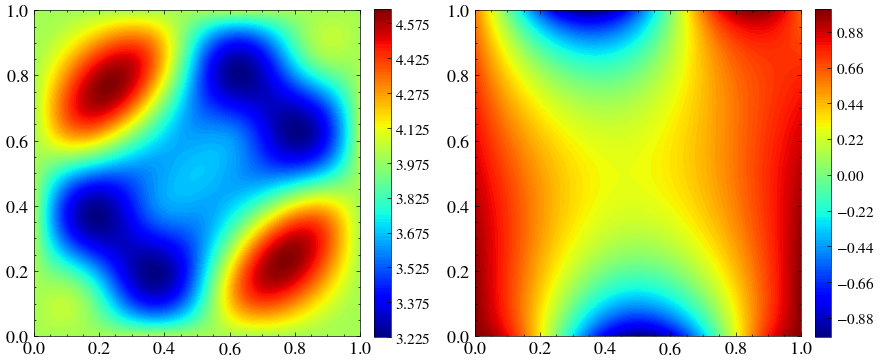

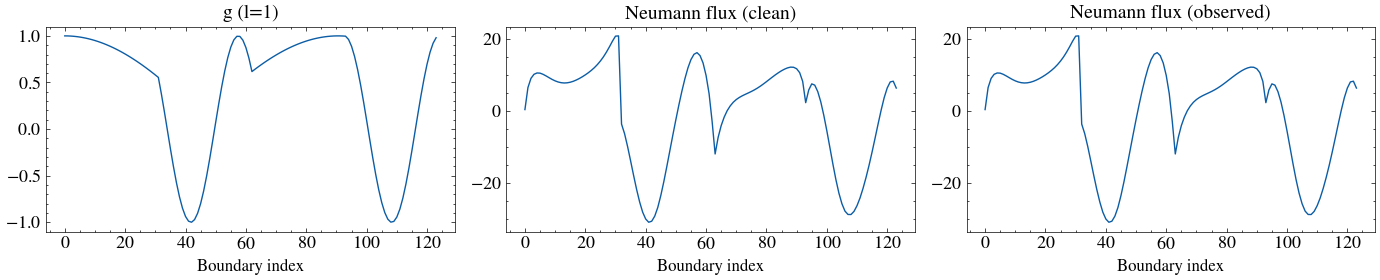

Prior predictive: a_err=0.3371, CRPS=0.8400, cov95=1.0000

  n_obs=62


  Boundary points: 62, normals: (62, 2)
  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=100.0, target=neumann


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

Inverting:   0%|          | 1/200 [00:03<12:45,  3.84s/it]

...

sample: 100%|█████████▉| 1995/2000 [00:42<00:00, 46.74it/s]

sample: 100%|██████████| 2000/2000 [00:42<00:00, 47.36it/s]

sample: 100%|██████████| 2000/2000 [00:42<00:00, 46.96it/s]

MCMC warmup: 205.6s, sampling: 42.6s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
 beta_a[0]     -0.65      0.00     -0.65     -0.65     -0.64   5706.53      1.00
 beta_a[1]      0.12      0.00      0.12      0.12      0.12   5095.51      1.00
 beta_a[2]     -0.73      0.00     -0.73     -0.73     -0.72   5802.27      1.00
 beta_a[3]      0.85      0.00      0.85      0.84      0.85   5667.52      1.00
 beta_a[4]      0.05      0.00      0.05      0.04      0.06   4836.84      1.00
 beta_a[5]      0.15      0.01      0.15      0.14      0.16   6831.88      1.00

Number of divergences: 0
ESS min=4836.8, R-hat max=1.0015, divergences=0/8000, [PASS] All diagnostics within thresholds


  Chi2 PPC: chi2=48.55, p=0.8938 (df=62)
Saved structured result to: /workspace/experiments/results/structured/sensor_sweep/eit_2026-06-14T17-33-42_seed7.json

  EIT — Sensor Count Sensitivity
  Condition                  CRPS(a)    Coverage    CI Width   Sharpness   Rel.L2(a)     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  n_obs=62                  0.011901     96.39%     0.075965    0.019391    0.005676           0      4836.8      1.0015    PASS



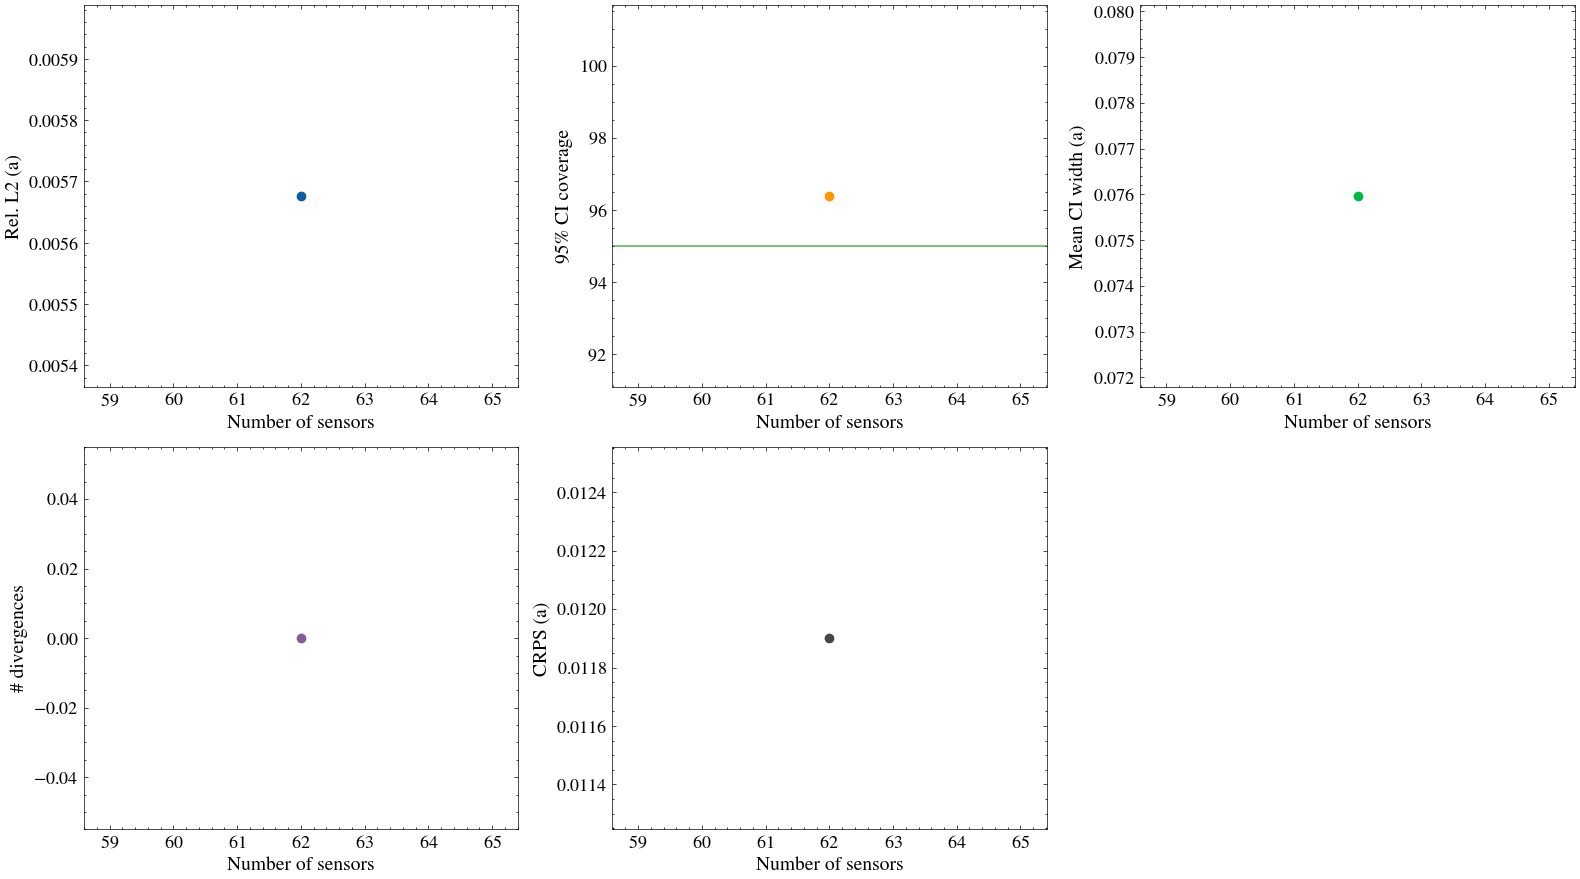

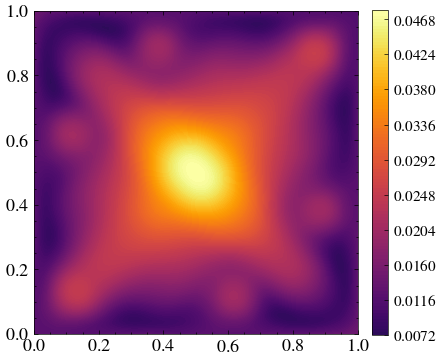

# Panels (a), (b), (c)... correspond to sensor count conditions above


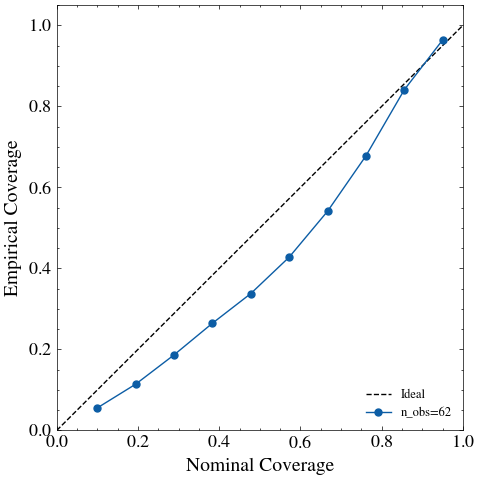

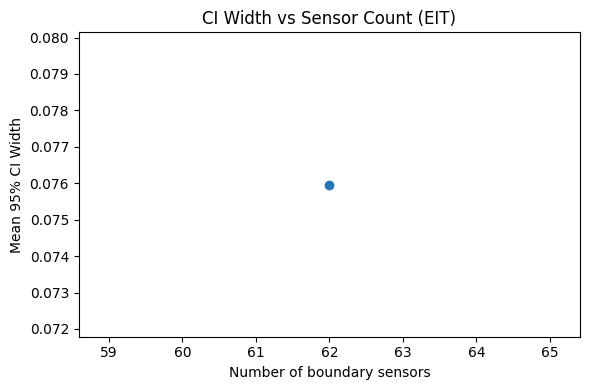

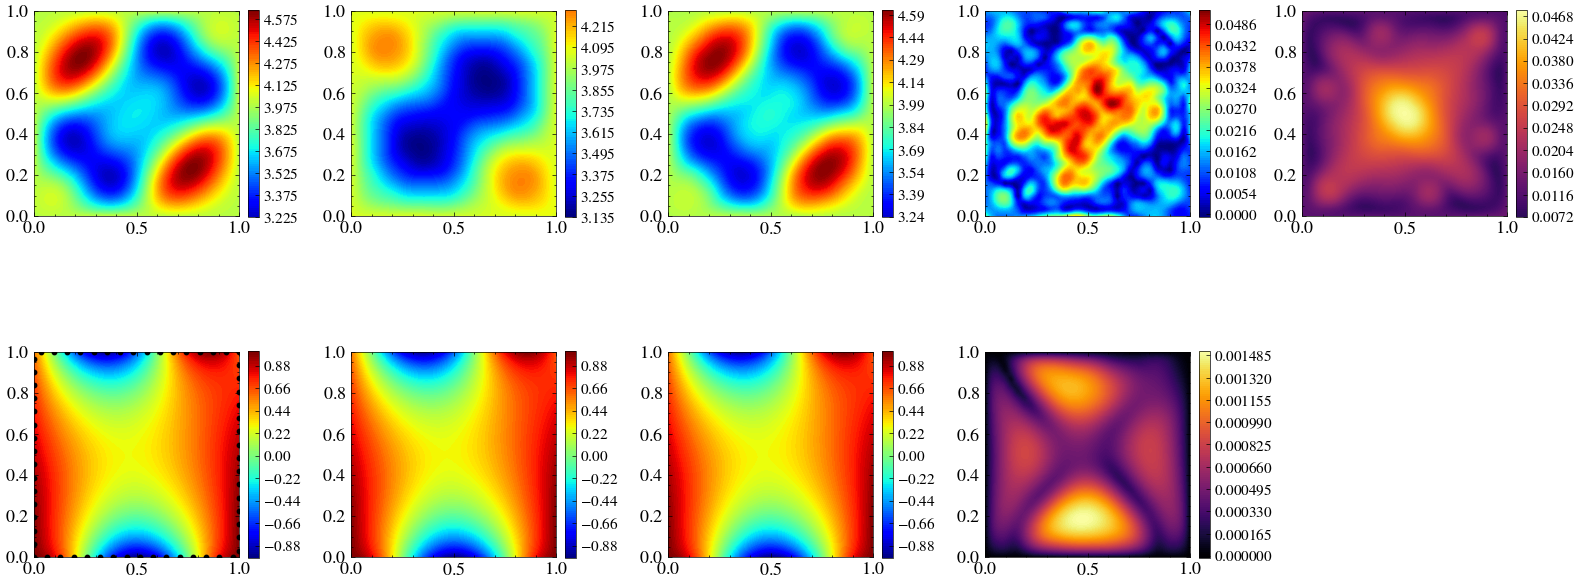

# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a
# (e) Ground truth u  (f) MAP u  (g) Posterior mean u  (h) Posterior std u

Bootstrap CIs on CRPS(a) at each sensor count:
         label      CRPS                  CI


      n_obs=62  0.01190  [0.01172, 0.01209]

n_obs=62 (sigma=0.100000, 4 chains x 2000 samples):
  ESS:  min=4836.8, mean=5656.8
  R-hat: max=1.0015, mean=1.0005
  Divergences: 0 / 8000
  MAP RMSE: 0.053785
   dim       ESS     R-hat        mean         std
     0    5706.5    1.0003     -0.6466      0.0023
     1    5095.5    1.0005      0.1186      0.0022
     2    5802.3    0.9999     -0.7256      0.0027
     3    5667.5    1.0010      0.8452      0.0018
     4    4836.8    1.0015      0.0495      0.0038
     5    6831.9    1.0000      0.1502      0.0059


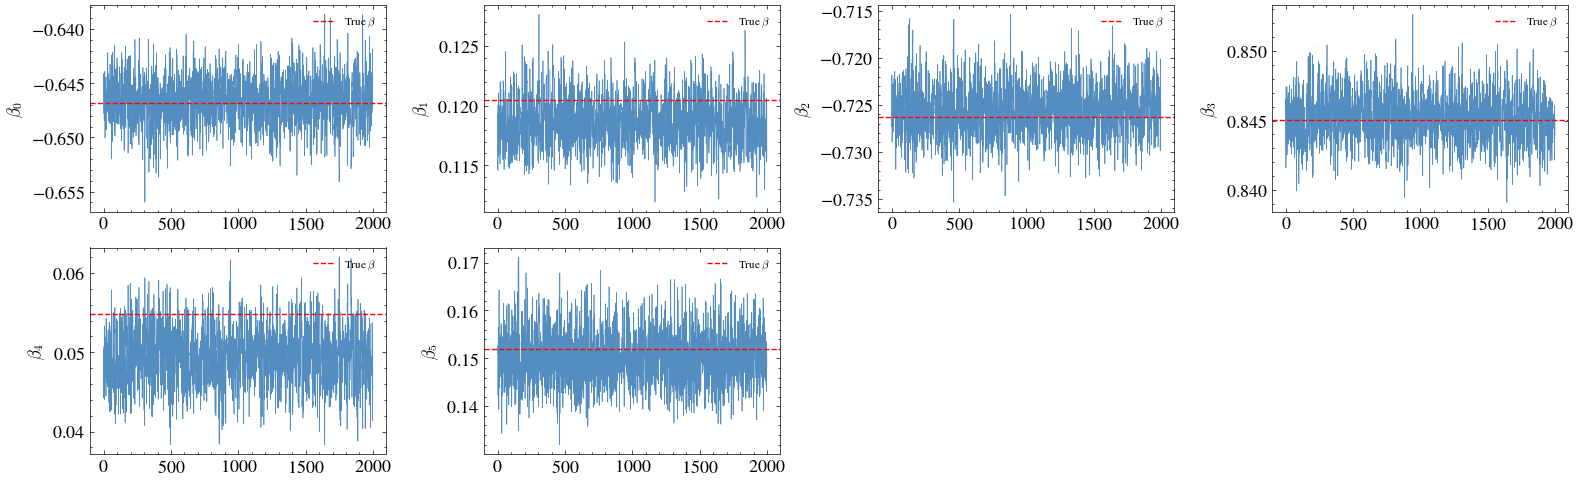

In [6]:
from results_schema import ExperimentResult
from datetime import datetime

def _to_mcmc_result(res):
    return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}")
    rng = random.PRNGKey(SEED)

    rng, key = random.split(rng)
    obs_indices_full = problem.sample_observation_indices(n_points, REF_N_OBS, 'random', key)
    obs_data_full = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices_full)
    x_full = obs_data_full['x_full']
    a_true = obs_data_full['a_true']
    u_true = obs_data_full.get('u_true', None)
    g_l = obs_data_full['g_l']

    FIGURE_DIR = Path(f'figures/sensor_sweep_eit/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    print(f"  x_full: {x_full.shape}, a_true: {a_true.shape}")
    print(f"  u_true available: {u_true is not None}, g_l = {int(g_l[0, 0])}")

    plot_eit_ground_truth(
        np.array(x_full[0]),
        np.array(a_true[0, :, 0]),
        u_true=np.array(u_true[0, :, 0]) if u_true is not None else None,
        save_path=FIGURE_DIR / 'ground_truth.png',
    )

    plot_eit_observation_data(
        x_bd=np.array(obs_data_full['x_obs'][0]),
        g_l=int(g_l[0, 0]),
        neumann_obs=np.array(obs_data_full['u_obs'][0, :, 0]),
        save_path=FIGURE_DIR / 'observation_data.png',
    )

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    sweep_results = []
    for n_obs in N_OBS_VALUES:
        rng, key = random.split(rng)
        res = run_condition(n_obs, key)
        sweep_results.append(res)

    # ### Save Structured Result
    experiment = ExperimentResult(
        experiment="sensor_sweep",
        problem="eit",
        experiment_type="sweep",
        sweep_var="n_obs",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        baseline=None,
        prior=build_prior_result(prior_metrics),
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots
    labels = [f'n_obs={r["n_obs"]}' for r in sweep_results]
    plot_sweep_summary_table(sweep_results, labels, title='EIT — Sensor Count Sensitivity')

    plot_sensor_sweep(sweep_results, save_path=FIGURE_DIR / 'sensor_sweep.png')

    x_np = np.array(x_full[0])
    stds = [res['a_std'] for res in sweep_results]
    labels = [res['label'] for res in sweep_results]

    plot_std_multi_panel(
        x_np, stds, labels, grid_shape=(32, 32),
        suptitle='Posterior Std: Sensor Count (EIT)',
        save_path=FIGURE_DIR / 'std_multi_panel.png',
    )
    print("# Panels (a), (b), (c)... correspond to sensor count conditions above")

    cal_list = [(r['cal_levels'], r['cal_empirical'], r['label']) for r in sweep_results]
    plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

    with plt.style.context(['default']):
        fig, ax = plt.subplots(figsize=(6, 4))
        n_obs_vals = [r['n_obs'] for r in sweep_results]
        widths = [r['ci_width'] for r in sweep_results]
        ax.plot(n_obs_vals, widths, 'o-', color='C0')
        ax.set_xlabel('Number of boundary sensors')
        ax.set_ylabel('Mean 95% CI Width')
        ax.set_title('CI Width vs Sensor Count (EIT)')
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / 'ci_width_vs_sensors.png', dpi=200, bbox_inches='tight')
        plt.show()

    x_np = np.array(x_full[0])
    a_true_np = np.array(a_true[0, :, 0])

    for res in sweep_results:
        u_kwargs = {}
        if u_true is not None:
            u_kwargs['u_true'] = np.array(u_true[0, :, 0])
            u_kwargs['u_map'] = np.array(res['u_map'][:, 0])
            u_kwargs['u_mean'] = res['u_mean']
            u_kwargs['u_std'] = res['u_std']
        plot_field_comparison(
            x_np, a_true_np,
            np.array(res['a_map'][:, 0]),
            res['a_mean'],
            res['a_std'],
            grid_shape=(32, 32),
            obs_coords=np.array(res['x_obs'][0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["n_obs"]}.png',
            **u_kwargs,
        )
        if u_true is not None:
            print("# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a")
            print("# (e) Ground truth u  (f) MAP u  (g) Posterior mean u  (h) Posterior std u")
        else:
            print("# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a")

    # ### Statistical Trend Analysis
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))

    rng_bs = np.random.default_rng(5)
    print("\nBootstrap CIs on CRPS(a) at each sensor count:")
    print(f"  {'label':>12s}  {'CRPS':>8s}  {'CI':>18s}")
    for res in sweep_results:
        a_np = np.array(res['a_pred'])
        if a_np.ndim == 3:
            a_np = a_np[:, :, 0]
        a_t = np.array(a_true[0, :, 0])
        ci = bootstrap_metric_ci(a_np, a_t, _crps_a, rng=rng_bs)
        print(f"  {res['label']:>12s}  {ci['estimate']:.5f}  [{ci['ci_lo']:.5f}, {ci['ci_hi']:.5f}]")

    # ### Diagnostics
    from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

    for res in sweep_results:
        beta_by_chain = res['beta_by_chain']
        ess = effective_sample_size(beta_by_chain)
        rhat = split_gelman_rubin(beta_by_chain)
        n_chains, n_samples_per_chain = beta_by_chain.shape[0], beta_by_chain.shape[1]
        total_samples = n_chains * n_samples_per_chain

        print(f"\n{res['label']} (sigma={res['sigma']:.6f}, {n_chains} chains x {n_samples_per_chain} samples):")
        print(f"  ESS:  min={float(ess.min()):.1f}, mean={float(ess.mean()):.1f}")
        print(f"  R-hat: max={float(rhat.max()):.4f}, mean={float(rhat.mean()):.4f}")
        print(f"  Divergences: {res['n_div']} / {total_samples}")
        print(f"  MAP RMSE: {res['map_a_err']:.6f}")

        beta_merged = beta_by_chain.reshape(-1, beta_by_chain.shape[-1])
        print(f"  {'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}  {'mean':>10s}  {'std':>10s}")
        for i in range(d):
            print(f"  {i:4d}  {float(ess[i]):8.1f}  {float(rhat[i]):8.4f}  "
                  f"{float(beta_merged[:, i].mean()):10.4f}  "
                  f"{float(beta_merged[:, i].std()):10.4f}")

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)

    for res in sweep_results:
        plot_trace(res['beta_for_trace'], beta_true_np, num_warmup=0,
                   save_path=FIGURE_DIR / f'trace_{res["label"]}.png')

## Cross-Seed Aggregation Summary

In [7]:
results = load_cross_seed_results("sensor_sweep", "eit")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (27 seeds: [7, 7, 7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123, 123, 123])


=== n_obs=31 ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0049      0.0009      0.0039      0.0060
crps_a                0.0110      0.0014      0.0096      0.0135
nll_a                -2.5293      0.0850     -2.5879     -2.3021
coverage_95           0.9824      0.0144      0.9639      0.9980
ci_width              0.0960      0.0170      0.0760      0.1292
mean_std              0.0245      0.0043      0.0194      0.0329
ess_min            3211.1302    965.9936   2212.2725   4836.8435
rhat_max              1.0013      0.0010      1.0002      1.0036
n_div                 2.7778      3.1050      0.0000     10.0000
